# 06 — Download Forest Registry (Metsaregister) Data

Downloads forest compartment geometries + IDs from the public WFS at
`gsavalik.envir.ee` (CC-BY 4.0). Then explores the data and prepares
for detailed attribute fetching.

**Source:** Kliimaministeeriumi GeoServer WFS
**Layers:** `mr_portaal:eraldis-rmk` (state), `mr_portaal:eraldis-era` (private)
**Area:** Lääne county (BBOX in EPSG:3301)

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

from carbon_dataset.forest_registry_wfs import download_laane_compartments

OUTPUT_DIR = Path("../data/raw/forest_registry")
OUTPUT_FILE = OUTPUT_DIR / "laane_eraldised.gpkg"

## Step 1: Download compartment geometries

~218k compartments, takes about 10 minutes.
Skip if already downloaded.

In [2]:
if OUTPUT_FILE.exists():
    print(f"Already downloaded: {OUTPUT_FILE}")
    print(f"Size: {OUTPUT_FILE.stat().st_size / 1024 / 1024:.1f} MB")
else:
    download_laane_compartments(OUTPUT_FILE)

Already downloaded: ..\data\raw\forest_registry\laane_eraldised.gpkg
Size: 105.1 MB


In [3]:
gdf = gpd.read_file(OUTPUT_FILE)
print(f"Loaded: {len(gdf):,} compartments")
print(f"Columns: {list(gdf.columns)}")
print(f"\nOwnership:")
print(gdf["ownership"].value_counts())
print(f"\nArea stats (ha):")
print(gdf["pindala"].describe())

Loaded: 218,133 compartments
Columns: ['eraldis_id', 'katastri_nr', 'kvartali_nr', 'yksus_id', 'eraldise_nr', 'pindala', 'staatus', 'ownership', 'geometry']

Ownership:
ownership
era    143588
rmk     74545
Name: count, dtype: int64

Area stats (ha):
count    218133.000000
mean          1.237341
std           1.528267
min           0.000000
25%           0.400000
50%           0.800000
75%           1.520000
max         106.530000
Name: pindala, dtype: float64


## Step 2: Explore the data

Text(141.11292489139308, 0.5, 'Northing')

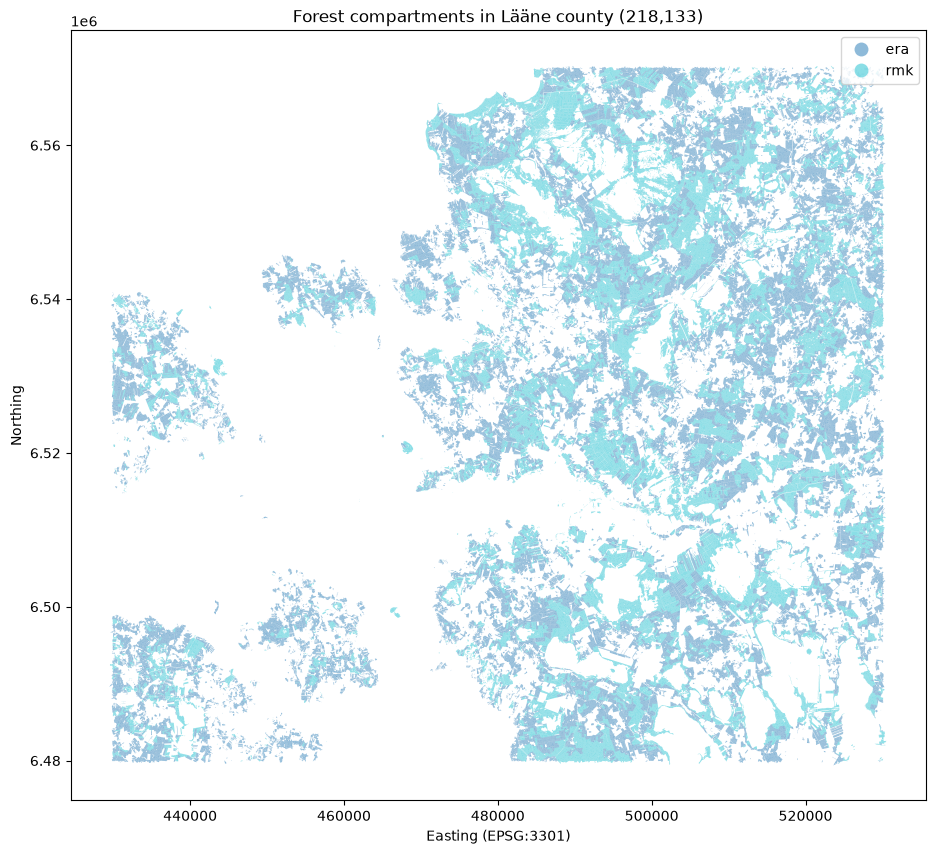

In [4]:
# Map overview
ax = gdf.plot(column="ownership", figsize=(12, 10), legend=True,
              alpha=0.5, markersize=0.1)
ax.set_title(f"Forest compartments in Lääne county ({len(gdf):,})")
ax.set_xlabel("Easting (EPSG:3301)")
ax.set_ylabel("Northing")

## Step 3: Spatial join with 1km grid

Link compartments to your existing grid cells.

In [5]:
grid_path = Path("../data/processed/v1/base_grid.gpkg")
if grid_path.exists():
    grid = gpd.read_file(grid_path)
    print(f"Grid: {len(grid)} cells")

    # Spatial join: which compartments fall in which grid cell
    joined = gpd.sjoin(gdf, grid, how="left", predicate="intersects")
    compartments_per_cell = joined.groupby("index_right").size()
    print(f"\nCompartments per grid cell:")
    print(compartments_per_cell.describe())
    print(f"\nGrid cells with forest data: {compartments_per_cell.index.nunique()}")
else:
    print(f"Grid not found at {grid_path}")
    print("Run data pipeline first, or adjust path.")

Grid: 2806 cells

Compartments per grid cell:
count    2449.000000
mean       48.385055
std        32.085873
min         1.000000
25%        21.000000
50%        46.000000
75%        72.000000
max       181.000000
dtype: float64

Grid cells with forest data: 2449


## Step 4: Prepare for detailed attribute fetching

The WFS only gives us IDs + geometry. Detailed forestry attributes
(species, age, volume, increment) need to be fetched separately.

Options:
- WMS GetFeatureInfo (200ms/request, parallelizable)
- Contact Keskkonnaagentuur for bulk export

In [6]:
# Save eraldis_ids for later fetching
ids = gdf[["eraldis_id", "pindala", "ownership"]].copy()
ids_path = OUTPUT_DIR / "laane_eraldis_ids.parquet"
ids.to_parquet(ids_path, index=False)
print(f"Saved {len(ids):,} IDs to {ids_path}")

# Random 10% sample for detailed fetch
sample = ids.sample(frac=0.1, random_state=42)
sample_path = OUTPUT_DIR / "laane_eraldis_sample_10pct.parquet"
sample.to_parquet(sample_path, index=False)
print(f"Saved 10% sample ({len(sample):,} IDs) to {sample_path}")

Saved 218,133 IDs to ..\data\raw\forest_registry\laane_eraldis_ids.parquet
Saved 10% sample (21,813 IDs) to ..\data\raw\forest_registry\laane_eraldis_sample_10pct.parquet


## Summary

- Downloaded 218k compartment polygons from public WFS
- Ready for spatial join with 1km grid
- 10% sample prepared for detailed attribute fetching
- Next: fetch species/age/volume/increment via WMS GetFeatureInfo